In [ ]:
from numba import cuda
import matplotlib.pyplot as plt
import numpy as np
import time

In [ ]:
hostSrc = plt.imread('./green-lake.jpg')

SCALE = 7
hostSrc = np.hstack([
    np.vstack([
        hostSrc for _ in range(SCALE)
    ])
    for _ in range(SCALE)
])

In [ ]:
H, W, _ = hostSrc.shape
C = 3

In [ ]:
print(f"Height: {H}")
print(f"Width: {W}")

Height: 15120
Width: 26880


## Compare speedup with 1D

In [ ]:
@cuda.jit
def gpu_grayscale(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
  dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g


blockSize = 64
gridSize = (H * W) // blockSize

def run():
  start_time = time.time()

  flatSrc = hostSrc.reshape((H*W, C))

  devSrc = cuda.to_device(flatSrc)
  devDst = cuda.device_array((H * W, C), np.uint8)

  gpu_grayscale[gridSize, blockSize](devSrc, devDst)

  flatDst = devDst.copy_to_host()
  hostDst = flatDst.reshape(H, W, C)

  end_time = time.time()

  return end_time - start_time

exeTimes = [run() for _ in range(30)]
sum(exeTimes) / len(exeTimes)


0.8268825848897298

In [ ]:
@cuda.jit
def gpu_grayscale(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
  tid = (tidx, tidy)
  g = np.uint8((src[*tid, 0] + src[*tid, 1] + src[*tid, 2]) / 3)
  dst[*tid, 0] = dst[*tid, 1] = dst[*tid, 2] = g


blockSize = (8, 8)
gridSize = (H//blockSize[0], W//blockSize[1])

def run():

  start_time = time.time()

  devSrc = cuda.to_device(hostSrc)
  devDst = cuda.device_array((H, W, C), np.uint8)

  gpu_grayscale[gridSize, blockSize](devSrc, devDst)

  hostDst = devDst.copy_to_host()

  end_time = time.time()

  return end_time - start_time

exeTimes = [run() for _ in range(30)]
sum(exeTimes) / len(exeTimes)

0.8775908629099528

## Varied Block Sizes Experiment

In [ ]:
def timeByBlockSize(blockSize: tuple[int, int], repeat=30):
  gridSize = (H//blockSize[0], W//blockSize[1])



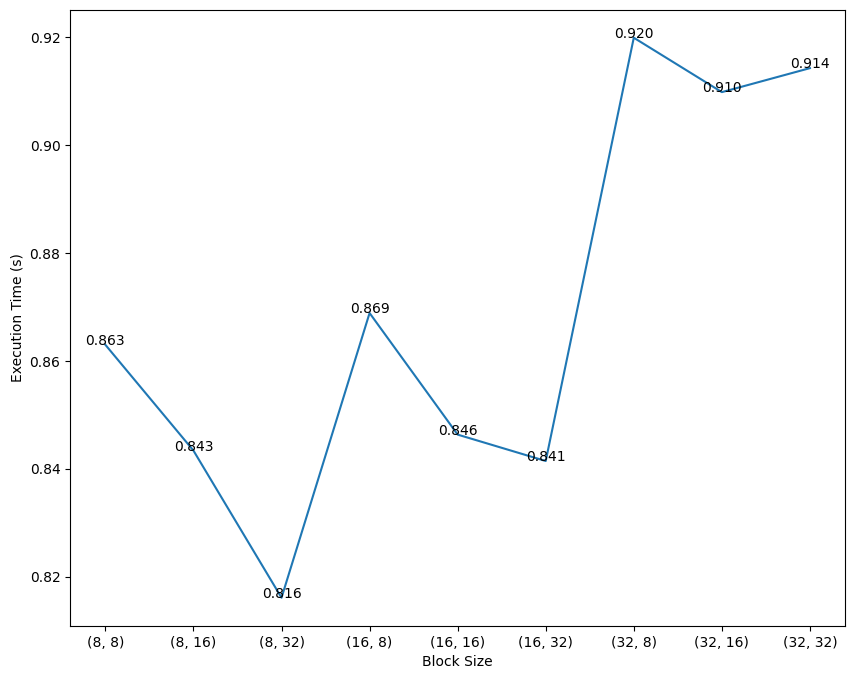

In [ ]:
def timeByBlockSize(blockSize: tuple[int, int], repeat=10):
  gridSize = (H//blockSize[0], W//blockSize[1])
  exeTimes = []
  for i in range(repeat):
    start_time = time.time()

    devSrc = cuda.to_device(hostSrc)
    devDst = cuda.device_array((H, W, C), np.uint8)

    gpu_grayscale[gridSize, blockSize](devSrc, devDst)

    hostDst = devDst.copy_to_host()

    end_time = time.time()

    exeTimes.append(end_time - start_time)

  return sum(exeTimes) / len(exeTimes)


def pair(L):
  for x in L:
    for y in L:
      yield (x, y)


power2s = list(range(3, 6))
blockSizes = list(pair([2**x for x in power2s]))
blockTicks = list(range(len(blockSizes)))

exeTimes = [timeByBlockSize(x, 30) for x in blockSizes]

plt.figure(figsize=(10, 8))
plt.plot(blockTicks, exeTimes)
plt.xticks(blockTicks, blockSizes)

plt.ylabel('Execution Time (s)')
plt.xlabel('Block Size')

for i, v in zip(blockTicks, exeTimes):
    plt.text(i, v, f"{v:.3f}", ha="center")
plt.show()